# EMS Response Time in New York City

In [ ]:
# Importing and installing necessary libraries. 
# !pip install pandas numpy matplotlib scipy statsmodels requests

import time
import math
import warnings
from urllib.parse import urlencode

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:,.3f}".format)

Defaulting to user installation because normal site-packages is not writeable
ok


In [ ]:
# Using the SODA API to fetch EMS incident data for 2024 directly from NYC Open Data.

DATASET_ID = "76xm-jjuj"
BASE_URL = f"https://data.cityofnewyork.us/resource/{DATASET_ID}.json"

YEAR = 2024
START_DATE = f"{YEAR}-01-01T00:00:00"
END_DATE = f"{YEAR+1}-01-01T00:00:00"

MAX_ROWS = None
PAGE_SIZE = 50_000

SELECT_COLS = [
    "incident_id",
    "incident_datetime",
    "initial_call_type",
    "initial_severity_level_code",
    "final_call_type",
    "final_severity_level_code",
    "first_assignment_datetime",
    "valid_dispatch_rspns_time_indc",
    "dispatch_response_seconds_qy",
    "first_activation_datetime",
    "first_on_scene_datetime",
    "valid_incident_rspns_time_indc",
    "incident_response_seconds_qy",
    "incident_travel_tm_seconds_qy",
    "first_to_hosp_datetime",
    "first_hosp_arrival_datetime",
    "incident_close_datetime",
    "held_indicator",
    "incident_disposition_code",
    "borough",
    "incident_dispatch_area",
    "zipcode",
    "policeprecinct",
    "citycouncildistrict",
    "communitydistrict",
    "communityschooldistrict",
    "congressionaldistrict",
    "reopen_indicator",
    "special_event_indicator",
    "standby_indicator",
    "transfer_indicator"
]

WHERE = (
    f"incident_datetime >= '{START_DATE}' "
    f"AND incident_datetime < '{END_DATE}' "
    "AND valid_incident_rspns_time_indc = 'Y' "
    "AND incident_response_seconds_qy IS NOT NULL "
    "AND borough IS NOT NULL"
)

def fetch_ems_data(max_rows=MAX_ROWS, page_size=PAGE_SIZE, app_token=None):
    records = []
    offset = 0
    headers = {}
    if app_token:
        headers["X-App-Token"] = app_token

    while True:
        remaining = None if max_rows is None else max_rows - len(records)
        if remaining is not None and remaining <= 0:
            break

        limit = page_size if remaining is None else min(page_size, remaining)
        params = {
            "$select": ",".join(SELECT_COLS),
            "$where": WHERE,
            "$limit": limit,
            "$offset": offset,
            "$order": "incident_datetime"
        }

        url = f"{BASE_URL}?{urlencode(params)}"
        response = requests.get(url, headers=headers, timeout=90)
        response.raise_for_status()
        batch = response.json()

        if not batch:
            break

        records.extend(batch)
        print(f"Downloaded {len(records):,} rows")
        offset += limit
        time.sleep(0.2)

    return pd.DataFrame.from_records(records)


APP_TOKEN = None

df_raw = fetch_ems_data(app_token=APP_TOKEN)
print(df_raw.shape)
df_raw.head()

Downloaded 50,000 rows
Downloaded 100,000 rows
Downloaded 150,000 rows
Downloaded 200,000 rows
Downloaded 250,000 rows
Downloaded 300,000 rows
Downloaded 350,000 rows
Downloaded 400,000 rows
Downloaded 450,000 rows
Downloaded 500,000 rows
Downloaded 550,000 rows
Downloaded 600,000 rows
Downloaded 650,000 rows
Downloaded 700,000 rows
Downloaded 750,000 rows
Downloaded 800,000 rows
Downloaded 850,000 rows
Downloaded 900,000 rows
Downloaded 950,000 rows
Downloaded 1,000,000 rows
Downloaded 1,050,000 rows
Downloaded 1,100,000 rows
Downloaded 1,150,000 rows
Downloaded 1,200,000 rows
Downloaded 1,250,000 rows
Downloaded 1,300,000 rows
Downloaded 1,350,000 rows
Downloaded 1,400,000 rows
Downloaded 1,450,000 rows
Downloaded 1,500,000 rows
Downloaded 1,542,590 rows
(1542590, 31)


,incident_id,incident_datetime,initial_call_type,initial_severity_level_code,final_call_type,final_severity_level_code,first_assignment_datetime,valid_dispatch_rspns_time_indc,dispatch_response_seconds_qy,first_activation_datetime,first_on_scene_datetime,valid_incident_rspns_time_indc,incident_response_seconds_qy,incident_travel_tm_seconds_qy,incident_close_datetime,held_indicator,incident_disposition_code,borough,incident_dispatch_area,zipcode,policeprecinct,citycouncildistrict,communitydistrict,communityschooldistrict,congressionaldistrict,reopen_indicator,special_event_indicator,standby_indicator,transfer_indicator,first_to_hosp_datetime,first_hosp_arrival_datetime
0,78843139,2024-01-01T00:00:03.000,INJURY,5,INJURY,5,2024-01-01T00:00:56.000,Y,53,2024-01-01T00:01:13.000,2024-01-01T00:06:36.000,Y,393,340,2024-01-01T00:56:41.000,N,93,QUEENS,Q5,11365,107,23,408,26,6,N,N,N,N,NaN,NaN
1,78843140,2024-01-01T00:00:14.000,CARD,3,CARD,3,2024-01-01T00:01:38.000,Y,84,2024-01-01T00:01:54.000,2024-01-01T00:07:24.000,Y,430,346,2024-01-01T01:19:22.000,N,82,BRONX,B2,10457,48,15,206,10,15,N,N,N,N,2024-01-01T00:26:07.000,2024-01-01T00:31:37.000
2,78843142,2024-01-01T00:00:45.000,RESPIR,4,RESPIR,4,2024-01-01T00:25:30.000,Y,1485,2024-01-01T00:25:40.000,2024-01-01T00:32:59.000,Y,1934,449,2024-01-01T01:37:04.000,Y,82,MANHATTAN,M9,10033,34,10,112,6,13,N,N,N,N,2024-01-01T00:50:41.000,2024-01-01T01:01:23.000
3,78843143,2024-01-01T00:00:55.000,BURNMI,4,BURNMI,4,2024-01-01T00:01:34.000,Y,39,2024-01-01T00:01:57.000,2024-01-01T00:22:50.000,Y,1315,1276,2024-01-01T02:36:27.000,N,82,BROOKLYN,K4,11208,75,37,305,19,8,N,N,N,N,2024-01-01T01:27:23.000,2024-01-01T01:44:10.000
4,78843144,2024-01-01T00:01:12.000,EDPC,7,EDPC,7,2024-01-01T00:01:23.000,Y,11,2024-01-01T00:01:54.000,2024-01-01T00:18:42.000,Y,1050,1039,2024-01-01T01:20:31.000,N,82,RICHMOND / STATEN ISLAND,S3,10309,123,51,503,31,11,N,N,N,N,2024-01-01T00:25:20.000,2024-01-01T00:36:32.000


In [ ]:
# Data cleaning and transformation.

df = df_raw.copy()

datetime_cols = [
    "incident_datetime",
    "first_assignment_datetime",
    "first_activation_datetime",
    "first_on_scene_datetime",
    "first_to_hosp_datetime",
    "first_hosp_arrival_datetime",
    "incident_close_datetime"
]
for col in datetime_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

numeric_cols = [
    "dispatch_response_seconds_qy",
    "incident_response_seconds_qy",
    "incident_travel_tm_seconds_qy",
    "policeprecinct",
    "citycouncildistrict",
    "communitydistrict",
    "communityschooldistrict",
    "congressionaldistrict",
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df["final_severity_num"] = pd.to_numeric(df["final_severity_level_code"], errors="coerce")
df["initial_severity_num"] = pd.to_numeric(df["initial_severity_level_code"], errors="coerce")

df["response_minutes"] = df["incident_response_seconds_qy"] / 60
df["dispatch_minutes"] = df["dispatch_response_seconds_qy"] / 60
df["travel_minutes"] = df["incident_travel_tm_seconds_qy"] / 60

df["incident_date"] = df["incident_datetime"].dt.date
df["month"] = df["incident_datetime"].dt.month
df["month_name"] = df["incident_datetime"].dt.strftime("%b")
df["hour"] = df["incident_datetime"].dt.hour
df["weekday"] = df["incident_datetime"].dt.day_name()
df["is_weekend"] = df["incident_datetime"].dt.dayofweek.isin([5, 6]).astype(int)

def assign_shift(hour):
    if 7 <= hour < 15:
        return "Day"
    elif 15 <= hour < 23:
        return "Evening"
    else:
        return "Night"

df["shift"] = df["hour"].apply(assign_shift)

for col in ["held_indicator", "reopen_indicator", "special_event_indicator", "standby_indicator", "transfer_indicator"]:
    if col in df.columns:
        df[col] = df[col].fillna("N").astype(str).str.upper().str.strip()

df["held_binary"] = (df["held_indicator"] == "Y").astype(int)
df["over_10min"] = (df["response_minutes"] > 10).astype(int)

df["borough"] = df["borough"].astype(str).str.upper().str.strip()
df = df[~df["borough"].isin(["", "NAN", "UNKNOWN", "NA"])]

df = df[
    (df["response_minutes"].notna()) &
    (df["response_minutes"] >= 0) &
    (df["response_minutes"] <= 180)
]

print(df.shape)
df[[
    "incident_datetime", "borough", "final_severity_level_code",
    "response_minutes", "dispatch_minutes", "travel_minutes",
    "hour", "weekday", "shift", "held_binary", "over_10min"
]].head()

(1539120, 46)


,incident_datetime,borough,final_severity_level_code,response_minutes,dispatch_minutes,travel_minutes,hour,weekday,shift,held_binary,over_10min
0,2024-01-01 00:00:03,QUEENS,5,6.550,0.883,5.667,0,Monday,Night,0,0
1,2024-01-01 00:00:14,BRONX,3,7.167,1.400,5.767,0,Monday,Night,0,0
2,2024-01-01 00:00:45,MANHATTAN,4,32.233,24.750,7.483,0,Monday,Night,1,1
3,2024-01-01 00:00:55,BROOKLYN,4,21.917,0.650,21.267,0,Monday,Night,0,1
4,2024-01-01 00:01:12,RICHMOND / STATEN ISLAND,7,17.500,0.183,17.317,0,Monday,Night,0,1


In [ ]:
# Checking for missing values in key variables.

missing = (
    df[[
        "incident_datetime", "borough", "final_severity_level_code",
        "response_minutes", "dispatch_minutes", "travel_minutes",
        "held_indicator", "hour", "weekday", "month"
    ]]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("missing_percent")
    .reset_index()
    .rename(columns={"index": "variable"})
)

print(missing)

,variable,missing_percent
0,travel_minutes,0.000
1,incident_datetime,0.000
2,borough,0.000
3,final_severity_level_code,0.000
4,response_minutes,0.000
5,dispatch_minutes,0.000
6,held_indicator,0.000
7,hour,0.000
8,weekday,0.000
9,month,0.000


In [ ]:
# Summary statistics by borough.

borough_summary = (
    df.groupby("borough")
    .agg(
        incidents=("incident_id", "count"),
        median_response_min=("response_minutes", "median"),
        mean_response_min=("response_minutes", "mean"),
        p25_response_min=("response_minutes", lambda x: np.percentile(x.dropna(), 25)),
        p75_response_min=("response_minutes", lambda x: np.percentile(x.dropna(), 75)),
        pct_over_10min=("over_10min", "mean"),
        pct_held=("held_binary", "mean")
    )
    .assign(
        pct_over_10min=lambda x: x["pct_over_10min"] * 100,
        pct_held=lambda x: x["pct_held"] * 100
    )
    .sort_values("median_response_min", ascending=False)
)

borough_summary

,incidents,median_response_min,mean_response_min,p25_response_min,p75_response_min,pct_over_10min,pct_held
borough,,,,,,,
BRONX,356427,9.683,15.798,6.517,15.983,47.948,24.814
MANHATTAN,363500,9.083,15.212,5.950,15.567,44.446,22.861
QUEENS,322956,8.800,11.377,6.017,13.150,41.232,8.862
BROOKLYN,428565,8.600,12.165,5.850,13.467,40.282,11.490
RICHMOND / STATEN ISLAND,67672,7.533,8.892,5.417,10.533,28.325,6.620


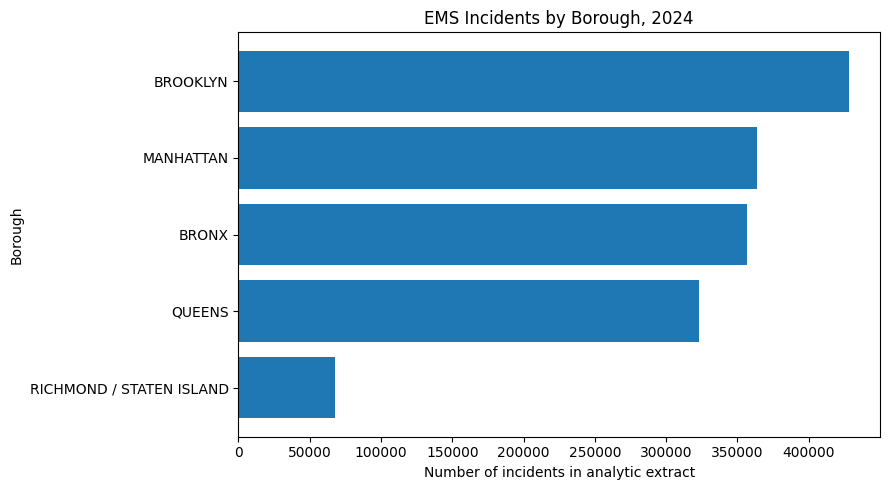

In [ ]:
# Graph 1: EMS Incidents by Borough

volume = df["borough"].value_counts().sort_values(ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(volume.index, volume.values)
plt.title(f"EMS Incidents by Borough, {YEAR}")
plt.xlabel("Number of incidents in analytic extract")
plt.ylabel("Borough")
plt.tight_layout()
plt.show()

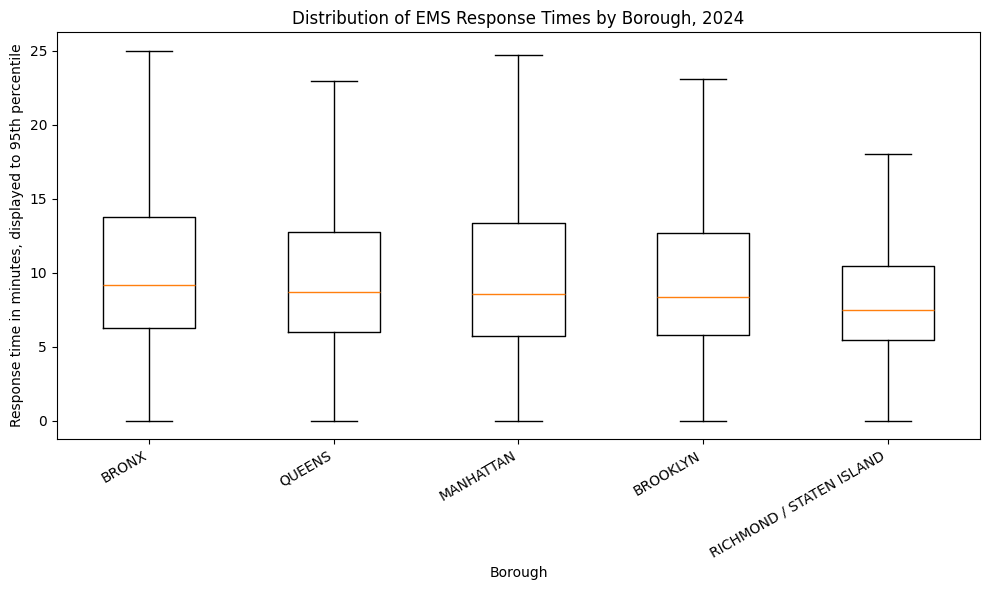

In [ ]:
# Graph 2: Response-Time Distribution by Borough

plot_df = df[df["response_minutes"] <= df["response_minutes"].quantile(0.95)].copy()
borough_order = (
    plot_df.groupby("borough")["response_minutes"]
    .median()
    .sort_values(ascending=False)
    .index
    .tolist()
)

data_to_plot = [plot_df.loc[plot_df["borough"] == b, "response_minutes"] for b in borough_order]

plt.figure(figsize=(10, 6))
plt.boxplot(data_to_plot, labels=borough_order, showfliers=False)
plt.title(f"Distribution of EMS Response Times by Borough, {YEAR}")
plt.ylabel("Response time in minutes, displayed to 95th percentile")
plt.xlabel("Borough")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

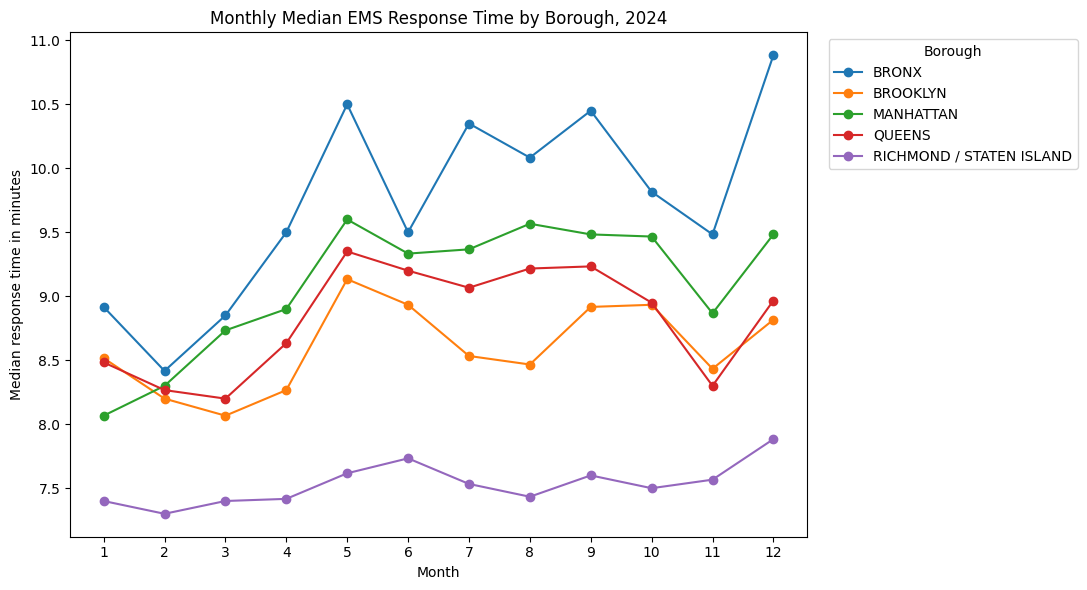

In [ ]:
# Graph 3: Monthly Median Response Time by Borough

monthly = (
    df.groupby(["month", "borough"])["response_minutes"]
    .median()
    .reset_index()
)

plt.figure(figsize=(11, 6))
for borough in sorted(monthly["borough"].unique()):
    temp = monthly[monthly["borough"] == borough]
    plt.plot(temp["month"], temp["response_minutes"], marker="o", label=borough)

plt.title(f"Monthly Median EMS Response Time by Borough, {YEAR}")
plt.xlabel("Month")
plt.ylabel("Median response time in minutes")
plt.xticks(range(1, 13))
plt.legend(title="Borough", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

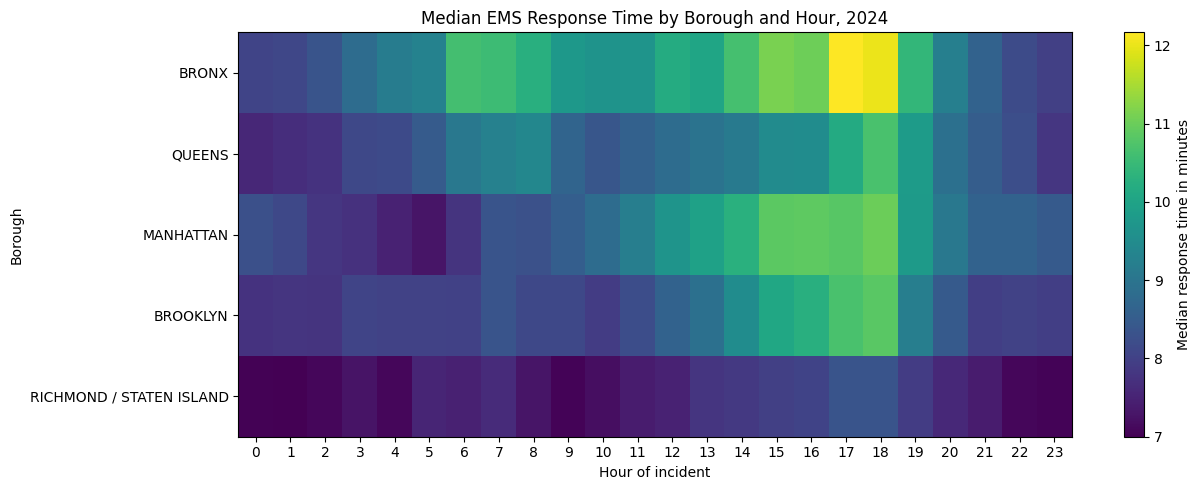

In [ ]:
# Graph 4: Hour-of-Day Heatmap

heat = (
    df.groupby(["borough", "hour"])["response_minutes"]
    .median()
    .reset_index()
    .pivot(index="borough", columns="hour", values="response_minutes")
)

heat = heat.loc[borough_order]

plt.figure(figsize=(13, 5))
plt.imshow(heat.values, aspect="auto")
plt.colorbar(label="Median response time in minutes")
plt.yticks(np.arange(len(heat.index)), heat.index)
plt.xticks(np.arange(24), heat.columns)
plt.title(f"Median EMS Response Time by Borough and Hour, {YEAR}")
plt.xlabel("Hour of incident")
plt.ylabel("Borough")
plt.tight_layout()
plt.show()

In [ ]:
# Statistical Analysis: Logistic Regression

model_df = df[
    [
        "over_10min", "borough", "final_severity_level_code",
        "shift", "weekday", "month", "held_binary"
    ]
].dropna().copy()

sev_counts = model_df["final_severity_level_code"].value_counts()
common_sev = sev_counts[sev_counts >= 100].index
model_df = model_df[model_df["final_severity_level_code"].isin(common_sev)]

reference_borough = model_df["borough"].value_counts().idxmax()
print("Reference borough:", reference_borough)

formula = (
    f"over_10min ~ C(borough, Treatment(reference='{reference_borough}')) "
    "+ C(final_severity_level_code) + C(shift) + C(weekday) + C(month) + held_binary"
)

logit_model = smf.logit(formula=formula, data=model_df).fit(maxiter=200)
print(logit_model.summary())

Reference borough: BROOKLYN
Optimization terminated successfully.
         Current function value: 0.559015
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             over_10min   No. Observations:              1539120
Model:                          Logit   Df Residuals:                  1539088
Method:                           MLE   Df Model:                           31
Date:                Wed, 03 Jun 2026   Pseudo R-squ.:                  0.1809
Time:                        15:04:22   Log-Likelihood:            -8.6039e+05
converged:                       True   LL-Null:                   -1.0504e+06
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                              coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------